# Advanced radiation and remote sensing

Manfred Brath, Oliver Lemke

## Exercise 1: Molecule absorption spectra

In [1]:
%matplotlib widget

import os
# Uncomment and adjust the following lines
# if ARTS_DATA_PATH is not set as environment variable
os.environ["ARTS_DATA_PATH"] = "/Users/wgblumbe/Code/rttools/arts_catalogs/arts-cat-data-snapshot-arts-2.5.6/"

import matplotlib.pyplot as plt
import numpy as np
import typhon as ty
from absorption_module import tag2tex, calculate_absxsec

# make plot folder, if it is not existing
os.makedirs("plots", exist_ok=True)

#speed of light 
c = ty.constants.c # m/s


### 1. Absorption spectra in the microwave spectral range (rotational spectra). 

Calculate the molecule absorption spectra of  

* $\mathrm{HCl}$
* $\mathrm{H_2O}$
* $\mathrm{O_3}$  

for a temperature of 200 K and 300 K.

* How does the rotational spectra change?
* Can you explain the changes?


In [8]:
# Define parameters
species = "H2O"
temperature = 300 # K 
pressure = 101325 # Pa

# Call ARTS to calculate absorption cross sections
freq, abs_xsec = calculate_absxsec(species, pressure, temperature)

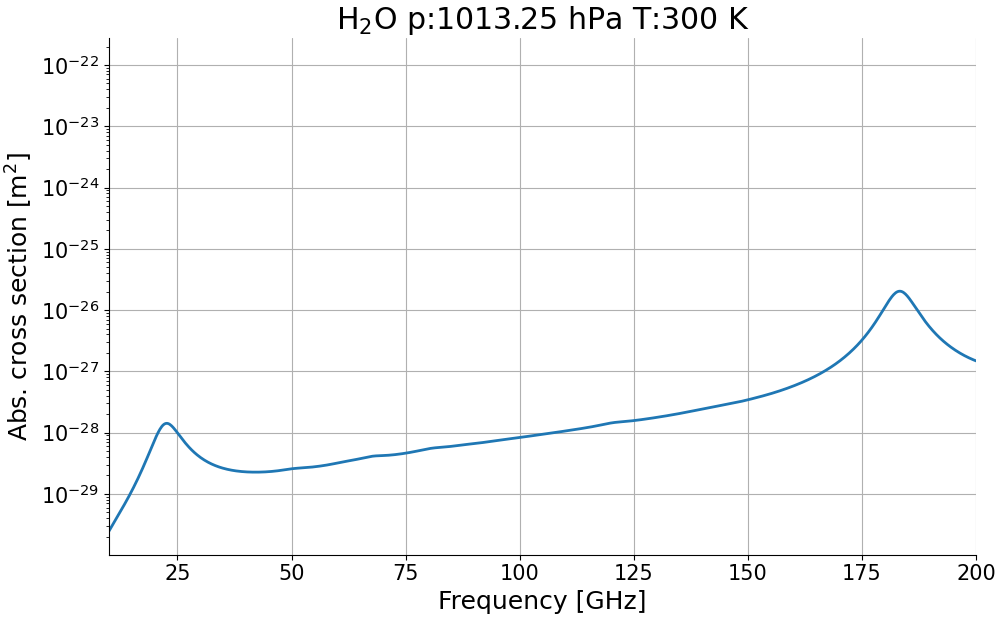

In [9]:
# Plot the results.
plt.style.use(ty.plots.styles("typhon"))

fig, ax = plt.subplots()
ax.plot(freq / 1e9, abs_xsec)
ax.set_xlim(freq.min() / 1e9, freq.max() / 1e9)
ax.set_xlim(10, 200)

#ax.set_ylim(bottom=0)
ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel(r"Abs. cross section [$\sf m^2$]")
ax.set_title(f"{tag2tex(species)} p:{pressure/100} hPa T:{temperature:0.0f} K")
ax.set_yscale('log')
ax.grid('True')

fig.savefig(  # Save figure.
    f"plots/plot_xsec_{species}_{pressure:.0f}Pa_{temperature:.0f}K.pdf"
)


### 2. Absorption spectra in the infrared spectral range (vibrational spectra). 

Calculate the molecule absorption spectra of  

* $\mathrm{CO_2}$
* $\mathrm{H_2O}$
* $\mathrm{O_3}$
* $\mathrm{O_2}$
* $\mathrm{N_2}$

for a temperature of 300 K.

Adjust the frequency limits using the keywordargument *fmin* and *fmax*  of `calculate_absxsec`. For plotting in the infrared range, it is common to use wavenumber in $\left[\text{cm}^{-1}\right]$  instead of frequency. Copy the python cells from above and adjust them.

* Can you explain the differences between $\mathrm{CO_2}$, $\mathrm{H_2O}$ and $\mathrm{O_3}$ on one side and $\mathrm{O_2}$ and $\mathrm{N_2}$ on the other side?

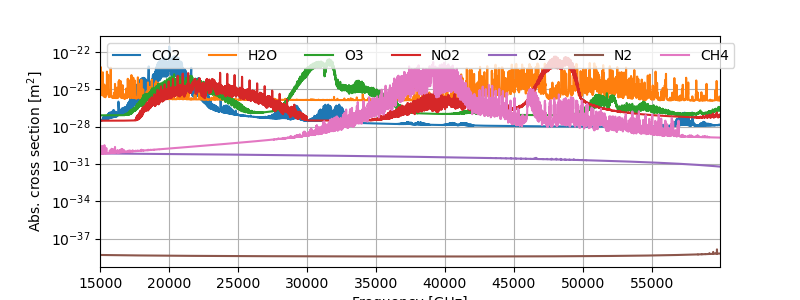

In [6]:
# Define parameters
species_list = ['CO2', 'H2O', 'O3', 'NO2', 'O2', 'N2', 'CH4']
#species = "H2O"
temperature = 300 # K 
pressure = 101325 # Pa

fig, ax = plt.subplots(figsize=(8,3))
for species in species_list:

    # Call ARTS to calculate absorption cross sections
    freq, abs_xsec = calculate_absxsec(species, pressure, temperature, fmin=14989622900000, fmax=59958491600000)

    ax.plot(freq / 1e9, abs_xsec, label=species)
    
ax.set_xlim(freq.min() / 1e9, freq.max() / 1e9)
ax.legend(loc=0, ncols=9)
#ax.set_xlim(10, 200)

#ax.set_ylim(bottom=0)
ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel(r"Abs. cross section [$\sf m^2$]")
#ax.set_title(f"{tag2tex(species)} p:{pressure/100} hPa T:{temperature:0.0f} K")
ax.set_yscale('log')
ax.grid('True')

#fig.savefig(  # Save figure.
#    f"plots/plot_xsec_{species}_{pressure:.0f}Pa_{temperature:.0f}K.pdf"
#)